# Prepare 5' eRNA for CREsted

In [1]:
suppressPackageStartupMessages({
    library(SingleCellExperiment)
    library(purrr)
    library(data.table)
    library(dplyr)
    library(Matrix)
    library(ggpubr)
})

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 32

In [2]:
io = list()
io$data = '/rds/project/rds-SDzz0CATGms/users/bt392/15_Kat_Atlas/results/data/'

In [3]:
CITE_eRNA_counts <- readMM(file.path(io$data, "CITE_eRNA_counts.mtx"))
meta = fread(file.path(io$data, 'CITE_metadata.csv'))
peaks = fread(file.path(io$data, 'CITE_eRNA_peaks.csv'))

In [4]:
peaks$peak = paste0(peaks$chr, ":", peaks$start, "-", peaks$end)

In [5]:
CITE_eRNA_counts[1:10, 1:10]

10 x 10 sparse Matrix of class "dgTMatrix"
                         
 [1,] . . . . . . . . . .
 [2,] . . . . . . . . . .
 [3,] . . . . . . . . . .
 [4,] . . . . . . . . . .
 [5,] . . . . . . . . . .
 [6,] . . . . . . . . . .
 [7,] . . . . . . . . . .
 [8,] . . . . . . . . . .
 [9,] . . . . . . . . . .
[10,] . . . . . . . . . .

In [6]:
dim(CITE_eRNA_counts)

[1] 195483 115715

In [7]:
rownames(CITE_eRNA_counts) = meta$V1
colnames(CITE_eRNA_counts) = peaks$peak

In [8]:
sce = SingleCellExperiment(list(counts = t(CITE_eRNA_counts)))

In [9]:
colData(sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('V1') %>% DataFrame()

In [10]:
sce

class: SingleCellExperiment 
dim: 115715 195483 
metadata(0):
assays(1): counts
rownames(115715): chr1:4699342-4699722 chr1:4705129-4705433 ...
  chrY:90819079-90820931 chrY:90822310-90823194
rowData names(0):
colnames(195483): AAACCTGCATCACAAC-LK_pool_1 AAACCTGCATGCCTTC-LK_pool_1
  ... TTTGTCATCCTCATTA-MNC_pool_4_5 TTTGTCATCTGGCGAC-MNC_pool_4_5
colData names(88): rna.samplename rna.sampleid ... n_counts annot1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [11]:
colnames(peaks)

[1] "V1"            "chr"           "start"         "end"          
 [5] "gene_ids"      "feature_types" "genome"        "n_cells"      
 [9] "peak_name"     "peak_score"    "peak_type"     "dist_to_TSS"  
[13] "closest_gene"  "peak_size"     "peak"

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


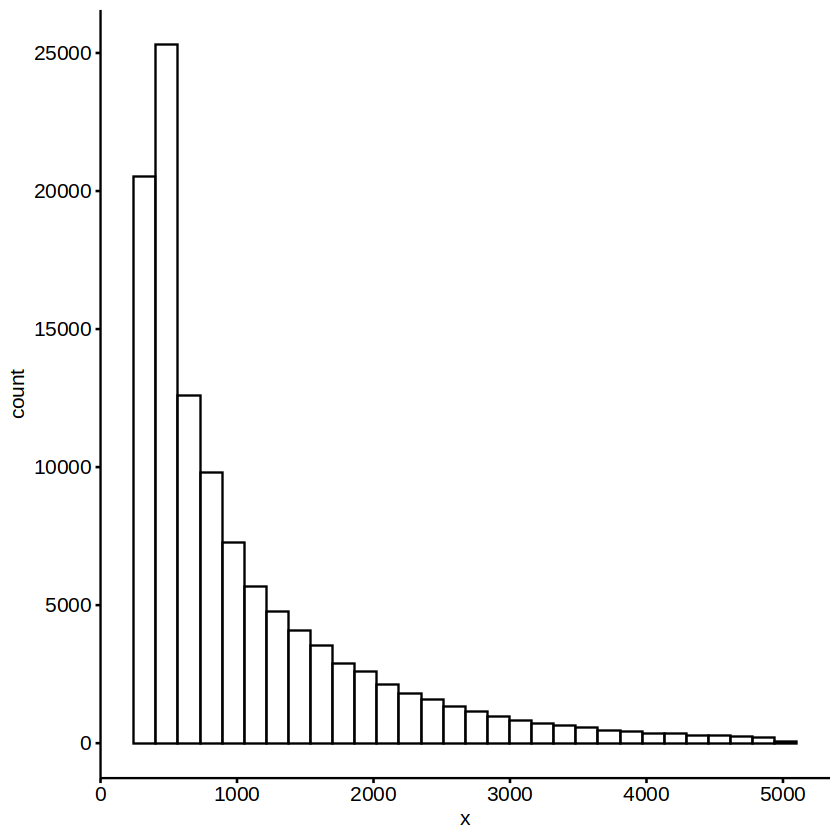

In [12]:
gghistogram(peaks[peak_size < 5000]$peak_size)

In [13]:
sce = sce[peaks[peak_size< 1000, peak],]
sce

class: SingleCellExperiment 
dim: 73316 195483 
metadata(0):
assays(1): counts
rownames(73316): chr1:4699342-4699722 chr1:4705129-4705433 ...
  chrY:90817784-90818297 chrY:90822310-90823194
rowData names(0):
colnames(195483): AAACCTGCATCACAAC-LK_pool_1 AAACCTGCATGCCTTC-LK_pool_1
  ... TTTGTCATCCTCATTA-MNC_pool_4_5 TTTGTCATCTGGCGAC-MNC_pool_4_5
colData names(88): rna.samplename rna.sampleid ... n_counts annot1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [53]:
# Pseudobulk single-cell data by cell type
sce_pseudobulk = scuttle::aggregateAcrossCells(sce, id=as.factor(sce$annot1), BPPARAM = BPPARAM, statistics = 'sum')

In [54]:
# normalize peak values for peak length (counts per kb)
counts(sce_pseudobulk) = counts(sce_pseudobulk) / peaks[peak_size< 1000, peak_size]

In [55]:
# log normalize
logcounts(sce_pseudobulk) <- log2(1e6*(sweep(counts(sce_pseudobulk),2,colSums(counts(sce_pseudobulk)),"/"))+1)

In [56]:
saveRDS(sce_pseudobulk, file.path(io$data, 'CITE_eRNA_sce_pseudobulk.rds'))

In [57]:
writeMM(Matrix(counts(sce_pseudobulk), sparse = T), file.path(io$data, "CITE_eRNA_pseudobulked.mtx"))

NULL

In [58]:
fwrite(peaks[peak_size< 1000,], file.path(io$data, "peaks_filted.csv"), sep = ',')
fwrite(data.frame(celltype = colData(sce_pseudobulk)$annot1), file.path(io$data, "meta_pseudobulk.csv"), sep = ',')

In [57]:
writeMM(Matrix(scale(counts(sce_pseudobulk)), sparse = T), file.path(io$data, "CITE_eRNA_pseudobulked_zscore.mtx"))

NULL